# 01 Exploratory Data Analysis

The [Microsoft Azure Predictive Maintenance Dataset](https://www.kaggle.com/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance/data) includes detailed records from 100 machines over the year 2015. It captures sensor data, failure events, maintenance activities, and machine metadata. The data is organized as follows:

* Telemetry Data (`PdM_telemetry.csv`): Hourly averages of voltage, rotation, pressure, and vibration for each machine.
* Error Logs (`PdM_errors.csv`): Logs of non-critical machine errors (do not cause shutdowns), timestamped and rounded to the nearest hour.
* Maintenance Records (`PdM_maint.csv`): Component replacements due to either: proactive or reactive maintenance.
* Failures (`PdM_failures.csv`): Subset of maintenance data showing failures that led to component replacements.
* Machine Metadata (`PdM_machines.csv`): Details about each machine’s model type and age.

In the following notebook we provide an Exploratory Analysis. 

## 1.1 Data Load

In [31]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
# Define path to raw data folder
DATA_RAW_PATH = Path("../data/raw/")

In [6]:
# Load files
telemetry_df = pd.read_csv(DATA_RAW_PATH / "PdM_telemetry.csv")
errors_df = pd.read_csv(DATA_RAW_PATH / "PdM_errors.csv")
failures_df = pd.read_csv(DATA_RAW_PATH / "PdM_failures.csv")
machines_df = pd.read_csv(DATA_RAW_PATH / "PdM_machines.csv")
maint_df = pd.read_csv(DATA_RAW_PATH / "PdM_maint.csv")

### 1.1.1 Telemetry

In [13]:
telemetry_df.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [20]:
telemetry_df.dtypes

datetime      object
machineID      int64
volt         float64
rotate       float64
pressure     float64
vibration    float64
dtype: object

In [21]:
telemetry_df['datetime'] = pd.to_datetime(telemetry_df['datetime'])

In [22]:
# Show statistical measure
telemetry_df.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


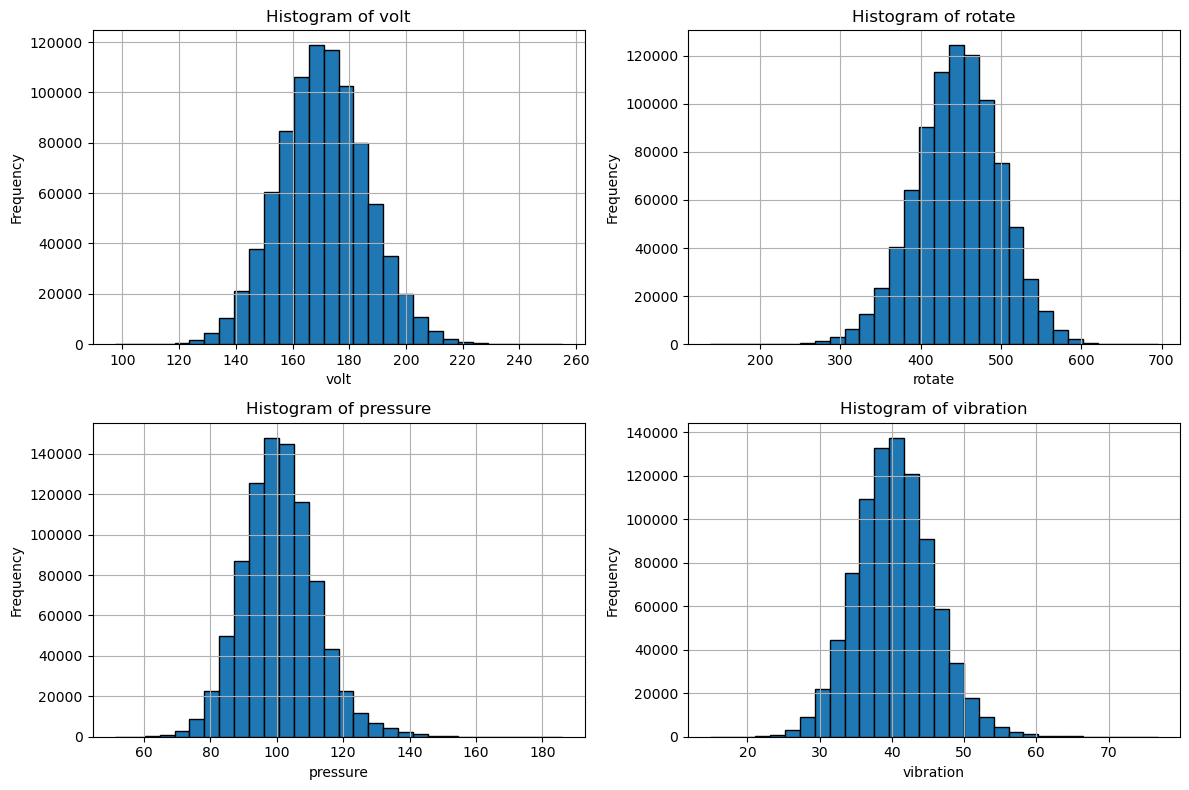

In [24]:
# Crear histogramas para variables numéricas
numeric_cols = ["volt", "rotate", "pressure", "vibration"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    telemetry_df[col].hist(bins=30, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Summary of findings:
* The `telemetry` dataset consists of 876,100 records collected between January 1st, 2015 and January 1st, 2016, across 100 machines (machine IDs from 1 to 100). The dataset includes four numerical sensor readings: `volt`, `rotate`, `pressure`, and `vibration`.
* The values of the physical measures: `volt`, `rotate`, `pressure`, and `vibration` follows a normal distribution. The values for each sensor are centered around their means with symmetrical percentiles. Standard deviations suggest low to moderate variability.
* No extreme outliers are immediately visible from summary statistics.

### 1.1.2 Errors

In [25]:
errors_df.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [27]:
errors_df['datetime'] = pd.to_datetime(errors_df['datetime'])

In [28]:
errors_df.describe()

,datetime,machineID
count,3919,3919.000000
mean,2015-07-01 03:34:18.586374144,51.044654
min,2015-01-01 06:00:00,1.000000
25%,2015-03-31 05:00:00,25.000000
50%,2015-07-01 06:00:00,51.000000
75%,2015-10-01 15:00:00,77.000000
max,2016-01-01 05:00:00,100.000000
std,NaN,28.954988


         count
errorID       
error1    1010
error2     988
error3     838
error4     727
error5     356


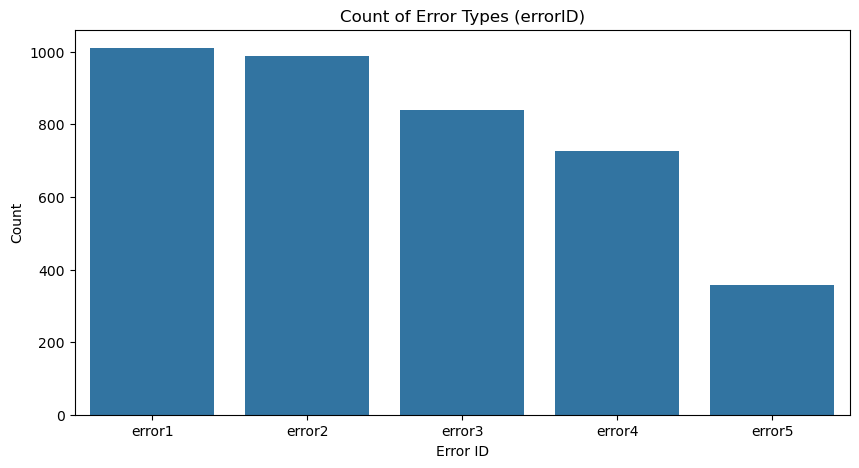

In [49]:
# Statistical summary of 'errorID'
error_id_summary = errors_df['errorID'].value_counts().to_frame(name="count")
print(error_id_summary)

# Plot bar chart for error types
plt.figure(figsize=(10, 5))
sns.countplot(data=errors_df, x='errorID', order=errors_df['errorID'].value_counts().index)
plt.title("Count of Error Types (errorID)")
plt.xlabel("Error ID")
plt.ylabel("Count")
plt.show()

Summary of findings:
* The `errors_df` dataset logs discrete error events for different machines across time. It contains 3,919 entries.
* Time coverage is consistent with the telemetry dataset.
* The `errorID` column is a categorical variable representing the type of error. The bar plot of error types shows that Error type error1 is the most recurrent.

### 1.1.3 Failures

In [10]:
failures_df.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [33]:
failures_df['datetime'] = pd.to_datetime(failures_df['datetime'])

In [38]:
failures_df.describe()

,datetime,machineID
count,761,761.000000
mean,2015-06-24 12:12:17.976346880,51.911958
min,2015-01-02 03:00:00,1.000000
25%,2015-03-23 06:00:00,24.000000
50%,2015-06-24 06:00:00,51.000000
75%,2015-09-23 06:00:00,79.000000
max,2015-12-31 06:00:00,100.000000
std,NaN,29.515542


         count
failure       
comp2      259
comp1      192
comp4      179
comp3      131


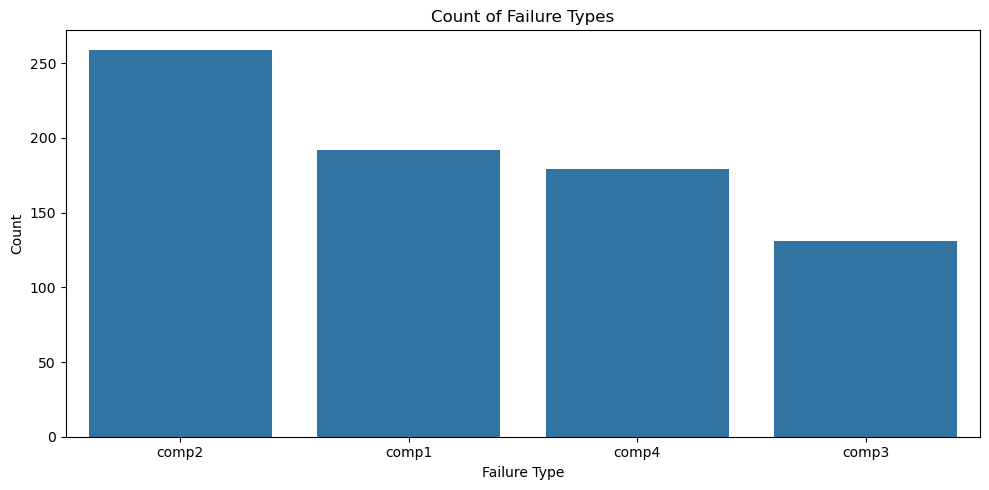

In [37]:
# Statistical summary of 'failure'
failure_summary = failures_df["failure"].value_counts().to_frame(name="count")
print(failure_summary)

# Plot bar chart for error failures
plt.figure(figsize=(10, 5))
sns.countplot(data=failures_df, x="failure", order=failures_df["failure"].value_counts().index)
plt.title("Count of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

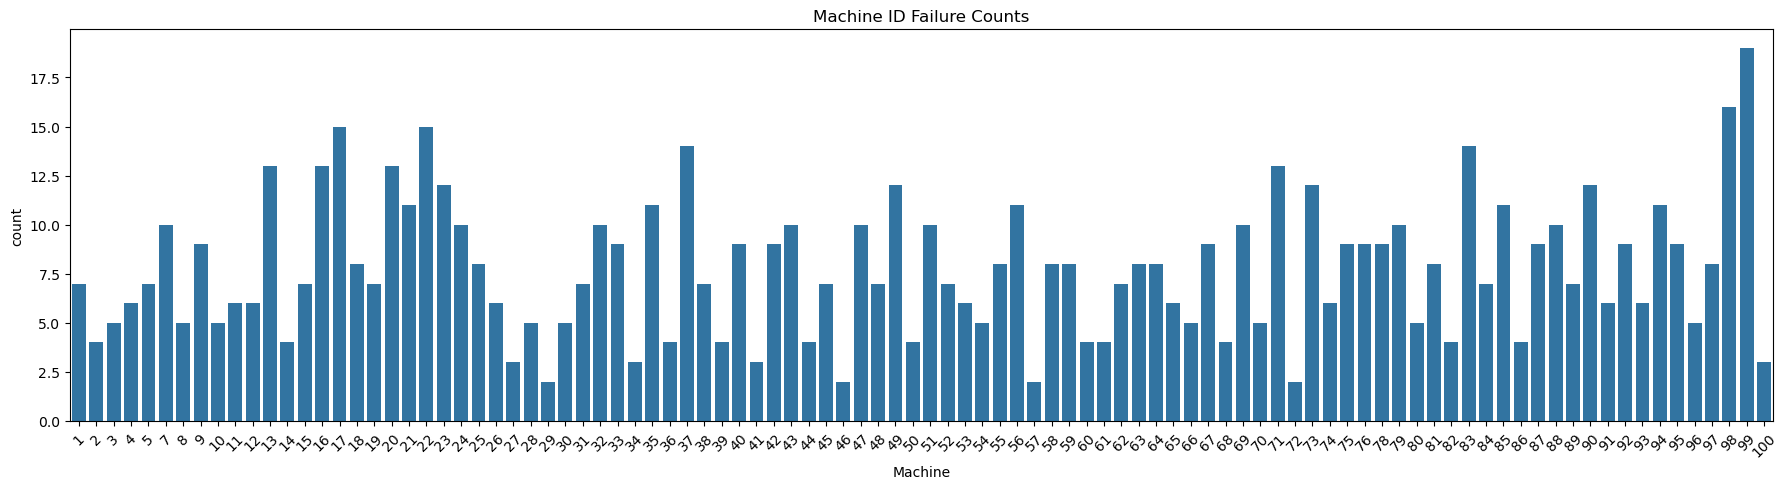

In [50]:
failures_by_machine = failures_df['machineID'].value_counts().sort_index()
failures_percent = 100 * failures_by_machine / failures_by_machine.sum()

failures_plot_df = pd.DataFrame({
    'machineID': failures_by_machine.index,
    'count': failures_by_machine.values,
    'percent': failures_percent.values
})

plt.figure(figsize=(18, 5))
sns.barplot(data=failures_plot_df, x='machineID', y='count')
plt.title("Machine ID Failure Counts")
plt.xticks(rotation=45)
plt.xlabel("Machine")
plt.tight_layout()

Summary of findings:
* The dataset logs 761 total failure events. Each record indicates a failure in a specific machine component (`failure`).
* Component 2 (comp2) fails most frequently, accounting for more than one-third of all failure events. This suggests it may be the most vulnerable or critical component in the system and deserves special attention in both monitoring and maintenance strategies.

### 1.1.4 Machines

In [11]:
machines_df.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


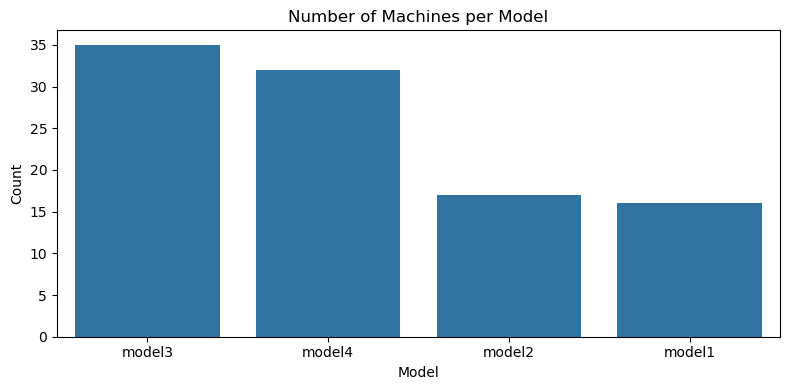

In [39]:
# Number of Machines per Model
plt.figure(figsize=(8, 4))
sns.countplot(data=machines_df, x="model", order=machines_df["model"].value_counts().index)
plt.title("Number of Machines per Model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

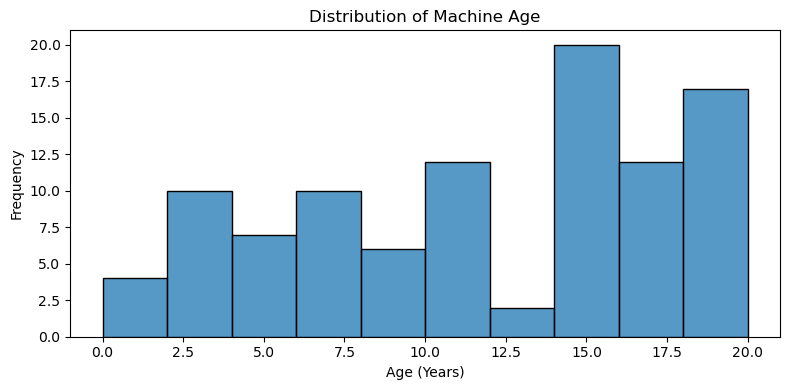

In [42]:
# Age Distribution 
plt.figure(figsize=(8, 4))
sns.histplot(data=machines_df, x="age", bins=10)
plt.title("Distribution of Machine Age")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

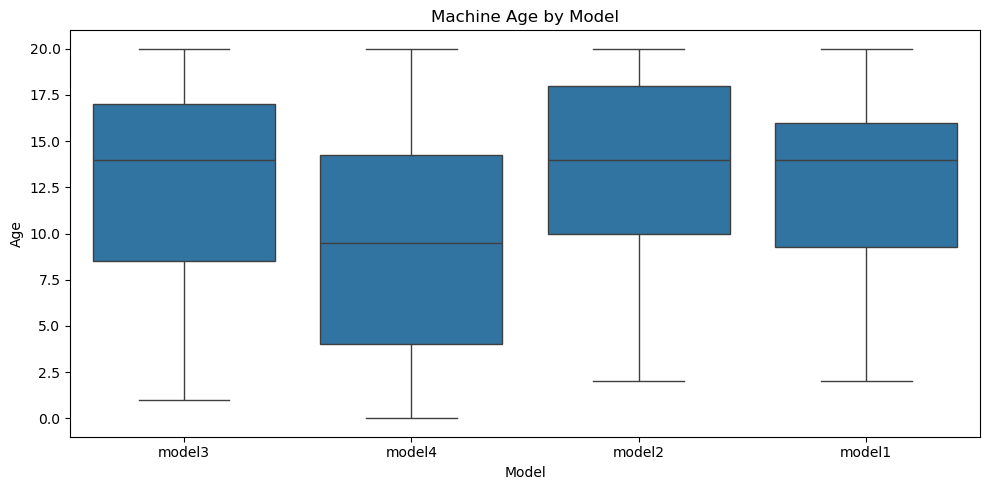

In [43]:
# Age Distribution per Model
plt.figure(figsize=(10, 5))
sns.boxplot(data=machines_df, x="model", y="age", order=machines_df["model"].value_counts().index)
plt.title("Machine Age by Model")
plt.xlabel("Model")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


Summary of findings:
* Model 3 and Model 4 are the most common, with 35 and 32 machines respectively. Model 2 and Model 1 are less represented, each with fewer than 20 machines.
* The machine age spans from 0 to 20 years.
* Model 2 has slightly older machines on average, with the highest median age and upper quartile. Model 4 tends to be newer, with many machines below 10 years of age.

### 1.1.5 Maintenance Components

In [12]:
maint_df.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


In [44]:
maint_df['datetime'] = pd.to_datetime(maint_df['datetime'])

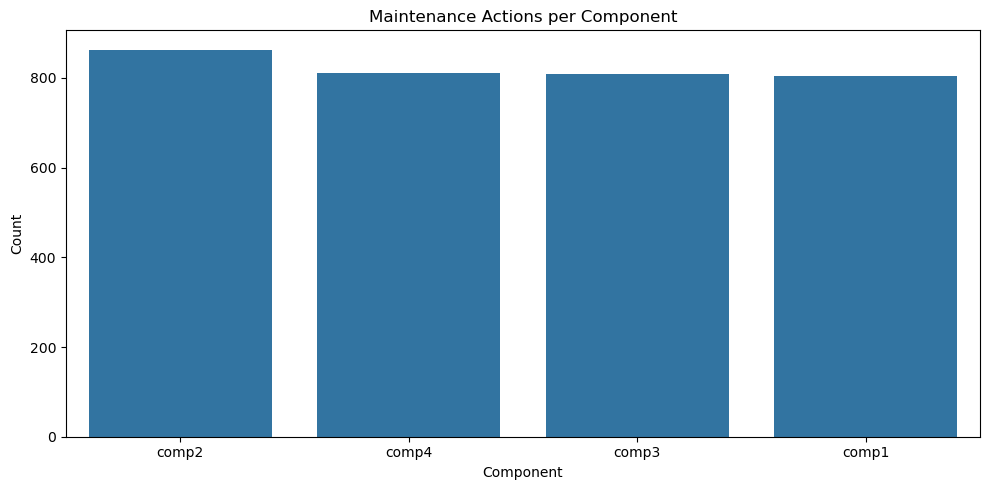

In [46]:
# Maintenance Actions by Component
plt.figure(figsize=(10, 5))
sns.countplot(data=maint_df, x='comp', order=maint_df['comp'].value_counts().index)
plt.title("Maintenance Actions per Component")
plt.xlabel("Component")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Summary of findings:
* Similar frequency across all components (comp1, comp2, comp3, comp4) indicating a balanced maintenance strategy.